In [1]:
!pip install -q kagglehub

import os
from PIL import Image
import kagglehub
import tensorflow as tf
import shutil

# 1. Download dataset via kagglehub
path = kagglehub.dataset_download("bhavikjikadara/dog-and-cat-classification-dataset")
print("Downloaded to:", path)


# Find PetImages path
pet_dir = os.path.join(path, "PetImages") if os.path.exists(os.path.join(path, "PetImages")) else path

# Create a clean dataset directory
target_dir = os.path.join("/content", "clean_dataset")
if os.path.exists(target_dir):
    shutil.rmtree(target_dir)
os.makedirs(os.path.join(target_dir, "Cat"), exist_ok=True)
os.makedirs(os.path.join(target_dir, "Dog"), exist_ok=True)

removed_count = 0
cats_count = 0
dogs_count = 0

print("Verifying and copying clean images...")
for category in ["Cat", "Dog"]:
    source_folder = os.path.join(pet_dir, category)
    target_folder = os.path.join(target_dir, category)
    if not os.path.exists(source_folder):
        continue
    for fname in os.listdir(source_folder):
        fpath = os.path.join(source_folder, fname)
        try:
            # Test decode exactly how TensorFlow loads images during training
            raw_bytes = tf.io.read_file(fpath)
            img = tf.io.decode_image(raw_bytes)
            # Only copy if channels are 1, 3, or 4
            if img.shape[-1] in [1, 3, 4]:
                shutil.copy(fpath, target_folder)
                if category == "Cat":
                    cats_count += 1
                else:
                    dogs_count += 1
            else:
                removed_count += 1
        except Exception:
            # File is corrupt or unreadable
            removed_count += 1

print(f"Done! Copied {cats_count} clean Cats and {dogs_count} clean Dogs to: {target_dir}")


Using Colab cache for faster access to the 'dog-and-cat-classification-dataset' dataset.
Downloaded to: /kaggle/input/dog-and-cat-classification-dataset
Verifying and copying clean images...
Done! Copied 12497 clean Cats and 12494 clean Dogs to: /content/clean_dataset


In [2]:
# import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import matplotlib.pyplot as plt

IMG_SIZE = (128, 128)
BATCH_SIZE = 32

# 1. Load clean datasets
train_ds = tf.keras.utils.image_dataset_from_directory(
    target_dir,
    validation_split=0.2,
    subset="training",
    seed=42,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="binary"
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    target_dir,
    validation_split=0.2,
    subset="validation",
    seed=42,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="binary"
)

AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.prefetch(buffer_size=AUTOTUNE)

Found 24991 files belonging to 2 classes.
Using 19993 files for training.
Found 24991 files belonging to 2 classes.
Using 4998 files for validation.


In [8]:
# 2. Build model with explicit Input layer and Data Augmentation
model = keras.Sequential([
    layers.Input(shape=(128, 128, 3)),

    # Data Augmentation Layers
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),

    # Preprocessing and CNN Layers
    layers.Rescaling(1./255),

    layers.Conv2D(32, (3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(64, (3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(128, (3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2)),

    layers.Flatten(),
    layers.Dense(64, activation="relu"),
    layers.Dropout(0.3),
    layers.Dense(1, activation="sigmoid")
])

model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

# 3. Train for 8 epochs
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=8
)


Epoch 1/8
625/625 ━━━━━━━━━━━━━━━━━━━━ 32s 44ms/step - accuracy: 0.6288 - loss: 0.6359 - val_accuracy: 0.6839 - val_loss: 0.5928
Epoch 2/8
625/625 ━━━━━━━━━━━━━━━━━━━━ 37s 43ms/step - accuracy: 0.7022 - loss: 0.5681 - val_accuracy: 0.7645 - val_loss: 0.4901
Epoch 3/8
625/625 ━━━━━━━━━━━━━━━━━━━━ 41s 43ms/step - accuracy: 0.7473 - loss: 0.5122 - val_accuracy: 0.7941 - val_loss: 0.4523
Epoch 4/8
625/625 ━━━━━━━━━━━━━━━━━━━━ 44s 47ms/step - accuracy: 0.7798 - loss: 0.4677 - val_accuracy: 0.8171 - val_loss: 0.4022
Epoch 5/8
625/625 ━━━━━━━━━━━━━━━━━━━━ 26s 42ms/step - accuracy: 0.8063 - loss: 0.4294 - val_accuracy: 0.8263 - val_loss: 0.3853
Epoch 6/8
625/625 ━━━━━━━━━━━━━━━━━━━━ 46s 50ms/step - accuracy: 0.8164 - loss: 0.4044 - val_accuracy: 0.8491 - val_loss: 0.3450
Epoch 7/8
625/625 ━━━━━━━━━━━━━━━━━━━━ 27s 43ms/step - accuracy: 0.8329 - loss: 0.3802 - val_accuracy: 0.8505 - val_loss: 0.3382
Epoch 8/8
625/625 ━━━━━━━━━━━━━━━━━━━━ 27s 43ms/step - accuracy: 0.8435 - loss: 0.3613 - val_accu

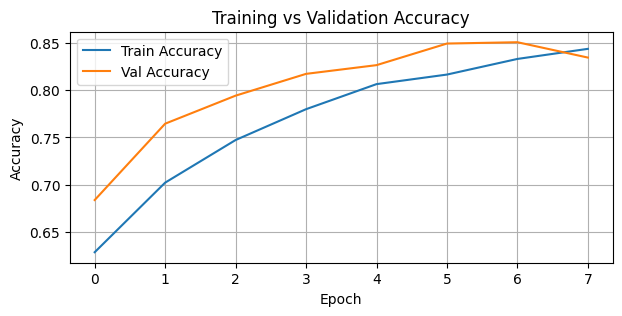

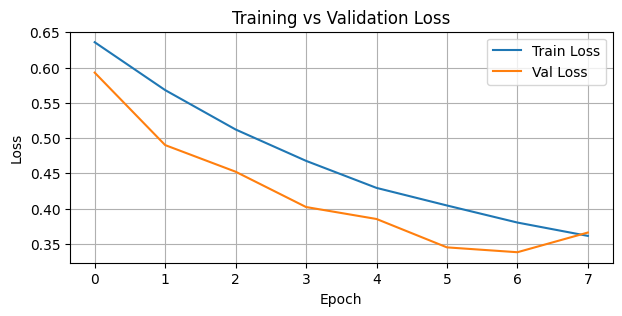

Saved as cats_dogs_model.keras


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [16]:
# 1. Accuracy Graph
plt.figure(figsize=(7, 3))
plt.plot(history.history["accuracy"], label="Train Accuracy")
plt.plot(history.history["val_accuracy"], label="Val Accuracy")
plt.title("Training vs Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.show()

# 2. Loss Graph
plt.figure(figsize=(7, 3))
plt.plot(history.history["loss"], label="Train Loss")
plt.plot(history.history["val_loss"], label="Val Loss")
plt.title("Training vs Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()

# 3. Save Model
model.save("cats_dogs_model.keras")
print("Saved as cats_dogs_model.keras")

try:
    from google.colab import files
    files.download("cats_dogs_model.keras")
except Exception:
    print("Downloaded file is available in the Colab file browser.")

In [17]:
!pip install -q fastapi uvicorn python-multipart

In [19]:
import io
import threading
import numpy as np
import tensorflow as tf
import uvicorn
from fastapi import FastAPI, File, HTTPException, UploadFile
from PIL import Image
from google.colab.output import eval_js

app = FastAPI(title="Cats vs Dogs CNN API")

# Load model from Colab's storage
MODEL_PATH = "cats_dogs_model.keras"
model = tf.keras.models.load_model(MODEL_PATH)
IMG_SIZE = (128, 128)

@app.get("/")
def home():
    return {"status": "online", "message": "FastAPI is running inside Colab"}

@app.post("/predict")
async def predict(file: UploadFile = File(...)):
    if not file.content_type.startswith("image/"):
        raise HTTPException(status_code=400, detail="Uploaded file must be an image.")

    contents = await file.read()
    image = Image.open(io.BytesIO(contents)).convert("RGB")
    image = image.resize(IMG_SIZE)

    img_array = np.array(image, dtype=np.float32)
    img_array = np.expand_dims(img_array, axis=0)

    raw_prediction = float(model.predict(img_array, verbose=0)[0][0])

    if raw_prediction >= 0.5:
        predicted_class = "Dog"
        confidence = raw_prediction
    else:
        predicted_class = "Cat"
        confidence = 1.0 - raw_prediction

    return {
        "predicted_class": predicted_class,
        "confidence": round(confidence, 4)
    }

# Run Uvicorn in a background thread so Colab does not freeze
def start_server():
    uvicorn.run(app, host="127.0.0.1", port=8000)

server_thread = threading.Thread(target=start_server, daemon=True)
server_thread.start()

# Generate the direct browser link to Swagger UI
base_proxy = eval_js("google.colab.kernel.proxyPort(8000)").rstrip("/")
docs_url = f"{base_proxy}/docs"

print("Server is active!")
print(f"Open Swagger UI here: {docs_url}")

INFO:     Started server process [1655]
INFO:     Waiting for application startup.
INFO:     Application startup complete.
ERROR:    [Errno 98] error while attempting to bind on address ('127.0.0.1', 8000): address already in use
INFO:     Waiting for application shutdown.
INFO:     Application shutdown complete.


Server is active!
Open Swagger UI here: https://8000-gpu-t4-s-kkb-usw1b1-ehj5lc0ava84-b.us-west1-1.prod.colab.dev/docs
